In [1]:
# Libraries
import os
import pandas as pd
import numpy as np

# Imports for model building
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout

# Imports for image transformations
from tensorflow.keras.layers import RandomFlip
from tensorflow.keras.layers import RandomZoom
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomTranslation
from tensorflow.keras.layers import RandomContrast
from tensorflow.keras.layers import RandomBrightness

# Callbacks
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Importing Keras utility for image dataset loading
from keras.utils import image_dataset_from_directory

# Reporting t
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from imblearn.metrics import classification_report_imbalanced

# Imports for visualizations
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
# Use this cell, whenever a change was made to the helper functions
# and the library needs to be reloaded in order to take effect
import helper
import importlib
importlib.reload(helper)

<module 'helper' from 'c:\\Users\\Thoma\\Downloads\\Python\\Github\\Covid-19_detection\\notebooks\\helper.py'>

In [3]:
# Variables and definitions
COVID_FOLDER = 'COVID-19_Radiography_Dataset'

### Trials with some constellations of CNN layers

##### Dataset loading and preprocessing

In [4]:
# Read in the images
train_ds, val_ds, class_names = helper.read_only_xray_images()

Created empty directory: c:\Users\Thoma\Downloads\Python\Github\Covid-19_detection\tmp_524654591
Made directory: c:\Users\Thoma\Downloads\Python\Github\Covid-19_detection\tmp_524654591\COVID\
Moved c:\Users\Thoma\Downloads\Python\Github\Covid-19_detection\COVID-19_Radiography_Dataset\COVID\masks to c:\Users\Thoma\Downloads\Python\Github\Covid-19_detection\tmp_524654591\COVID\masks
Made directory: c:\Users\Thoma\Downloads\Python\Github\Covid-19_detection\tmp_524654591\Lung_Opacity\
Moved c:\Users\Thoma\Downloads\Python\Github\Covid-19_detection\COVID-19_Radiography_Dataset\Lung_Opacity\masks to c:\Users\Thoma\Downloads\Python\Github\Covid-19_detection\tmp_524654591\Lung_Opacity\masks
Made directory: c:\Users\Thoma\Downloads\Python\Github\Covid-19_detection\tmp_524654591\Normal\
Moved c:\Users\Thoma\Downloads\Python\Github\Covid-19_detection\COVID-19_Radiography_Dataset\Normal\masks to c:\Users\Thoma\Downloads\Python\Github\Covid-19_detection\tmp_524654591\Normal\masks
Made directory: c:

In [5]:
# Number of batches in the training dataset
print("Number of batch in train_ds:", train_ds.cardinality().numpy())

# Number of batches in the validation dataset
print("Number of batch in val_ds:", val_ds.cardinality().numpy())

# Let's check compatible input format for VGG16
for images, labels in train_ds.take(1):
    print('Batch shape:', images.shape, labels.shape)
    # Show some sample image shapes and according labels (should be shuffled!)
    for image, label in zip(images.numpy(),labels.numpy()):
        print(image.shape, label)

Number of batch in train_ds: 530
Number of batch in val_ds: 133
Batch shape: (32, 224, 224, 3) (32,)
(224, 224, 3) 1
(224, 224, 3) 2
(224, 224, 3) 2
(224, 224, 3) 3
(224, 224, 3) 1
(224, 224, 3) 2
(224, 224, 3) 0
(224, 224, 3) 1
(224, 224, 3) 2
(224, 224, 3) 0
(224, 224, 3) 2
(224, 224, 3) 2
(224, 224, 3) 1
(224, 224, 3) 2
(224, 224, 3) 1
(224, 224, 3) 3
(224, 224, 3) 2
(224, 224, 3) 2
(224, 224, 3) 2
(224, 224, 3) 2
(224, 224, 3) 1
(224, 224, 3) 0
(224, 224, 3) 0
(224, 224, 3) 1
(224, 224, 3) 1
(224, 224, 3) 0
(224, 224, 3) 1
(224, 224, 3) 1
(224, 224, 3) 1
(224, 224, 3) 1
(224, 224, 3) 0
(224, 224, 3) 0


In [6]:
# We have imbalanced data, hence let's calculate class_weights to give it the model
from collections import Counter

# Count occurrences of each class
class_counts = Counter()
total_count = 0
for images, labels in train_ds:
    for label in labels.numpy():  # Convert tensor to numpy
        class_counts[label] += 1
        total_count += 1

# Convert label indices to class names
class_counts_named = {class_names[idx]: count for idx, count in class_counts.items()}
print("Class Counts:", class_counts_named)

class_weights_dict = { class_label: total_count / (len(class_counts) * class_counts[class_label])
                 for class_label, class_count in class_counts.items() }
print('Class Weights:', class_weights_dict)

Class Counts: {'Viral Pneumonia': 1048, 'Lung_Opacity': 4847, 'Normal': 8134, 'COVID': 2903}
Class Weights: {np.int32(3): 4.03912213740458, np.int32(1): 0.8733237053847741, np.int32(2): 0.5204081632653061, np.int32(0): 1.4581467447468137}


In [7]:
# Preprocessing for pretrained models in the same way
# the preprocessor comes with the pretrained model library
from tensorflow.keras.applications.vgg16 import preprocess_input

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))

#### Try with VGG16 (imagenet pretrained)

In [8]:
# This model name for saving and loading
model_name = 'vgg16_augmented_' + str(len(class_names)) + '-classes.keras'

In [9]:
# Imports for using a pre-trained model
from tensorflow.keras.applications.vgg16 import VGG16

# VGG16 model
base_model = VGG16(weights='imagenet', include_top=False)

# Freeze the layers of VGG16
base_model.trainable = False

# Model creation using the Functional API
inputs = Input(shape=(224, 224, 3))

# Apply augmentations
# Apply random translation of up to +-20% in either direction
x = RandomTranslation(0.2, 0.2)(inputs)
# Apply random zoom +-20%
x = RandomZoom(0.2)(x)
# Apply random horizontal and vertical flipping to images
x = RandomFlip("horizontal_and_vertical")(x)
# Perform random rotation of up to 20% (in radians) in either direction
x = RandomRotation(0.2)(x)
# Randomly adjust image contrast by ±20%
x = RandomContrast(factor=0.2)(x)
# Randomly adjust image brightness by ±10%
x = RandomBrightness(factor=0.1)(x)

# Build the model
x = base_model(x)
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(rate=0.2)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(rate=0.2)(x)
outputs = Dense(len(class_names), activation='softmax')(x)

vgg16 = Model(inputs=inputs, outputs=outputs)

In [10]:
# Applied Callbacks
early_stopping = EarlyStopping(
                                patience=3, # Wait for 5 epochs before applying
                                min_delta=0.01, # If the loss function doesn't change by 1% after 3 epochs, either up or down, we stop
                                verbose=1, # Display the epoch at which training stops
                                mode='min',
                                monitor='val_loss')

# A learning rate reduction callback to reduce the learning rate when the validation loss stagnates
reduce_learning_rate = ReduceLROnPlateau(
                                    monitor="val_loss",
                                    patience=3, # If val_loss stagnates for 3 consecutive epochs based on the min_delta value
                                    min_delta=0.01,
                                    factor=0.1,  # Reduce the learning rate by a factor of 0.1
                                    cooldown=3,  # Wait 3 epochs before retrying
                                    verbose=1)

In [11]:
# Compile with first idea of appropriate parameters
vgg16.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Print how it looks like
vgg16.summary()

# Convert summary to DataFrame and display it (for copy and paste purposes)
from helper import model_summary_to_df
df_summary = model_summary_to_df(vgg16)
display(df_summary)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 224, 224, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ (None, 224, 224, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,766,852 (60.15 MB)

 Trainable params: 1,052,164 (4.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

,Layer Name (type),Output Shape,Param Count
0,input_layer_1 (InputLayer),"(None, 224, 224, 3)",0
1,random_translation,"(None, 224, 224, 3)",0
2,(RandomTranslation),,
3,random_zoom (RandomZoom),"(None, 224, 224, 3)",0
4,random_flip (RandomFlip),"(None, 224, 224, 3)",0
5,random_rotation,"(None, 224, 224, 3)",0
6,(RandomRotation),,
7,random_contrast,"(None, 224, 224, 3)",0
8,(RandomContrast),,
9,random_brightness,"(None, 224, 224, 3)",0


In [13]:
# Train it with the entire dataset (takes very long!)
history_model = vgg16.fit(train_ds,
                          epochs=50,
                          validation_data=val_ds,
                          class_weight=class_weights_dict,
                          callbacks=[reduce_learning_rate])

Epoch 1/50
530/530 ━━━━━━━━━━━━━━━━━━━━ 520s 977ms/step - accuracy: 0.6086 - loss: 0.9835 - val_accuracy: 0.4193 - val_loss: 2.1989 - learning_rate: 0.0010
Epoch 2/50
530/530 ━━━━━━━━━━━━━━━━━━━━ 525s 991ms/step - accuracy: 0.7216 - loss: 0.6107 - val_accuracy: 0.5509 - val_loss: 1.1050 - learning_rate: 0.0010
Epoch 3/50
530/530 ━━━━━━━━━━━━━━━━━━━━ 566s 1s/step - accuracy: 0.7486 - loss: 0.5610 - val_accuracy: 0.4399 - val_loss: 1.5040 - learning_rate: 0.0010
Epoch 4/50
530/530 ━━━━━━━━━━━━━━━━━━━━ 565s 1s/step - accuracy: 0.7445 - loss: 0.5583 - val_accuracy: 0.6246 - val_loss: 1.0172 - learning_rate: 0.0010
Epoch 5/50
530/530 ━━━━━━━━━━━━━━━━━━━━ 565s 1s/step - accuracy: 0.7633 - loss: 0.5001 - val_accuracy: 0.6048 - val_loss: 1.3314 - learning_rate: 0.0010
Epoch 6/50
530/530 ━━━━━━━━━━━━━━━━━━━━ 565s 1s/step - accuracy: 0.7634 - loss: 0.5012 - val_accuracy: 0.6416 - val_loss: 1.0699 - learning_rate: 0.0010
Epoch 7/50
530/530 ━━━━━━━━━━━━━━━━━━━━ 0s 857ms/step - accuracy: 0.7734 - l

In [14]:
# Save the model for potential later use
vgg16.save(model_name)

##### Evalution

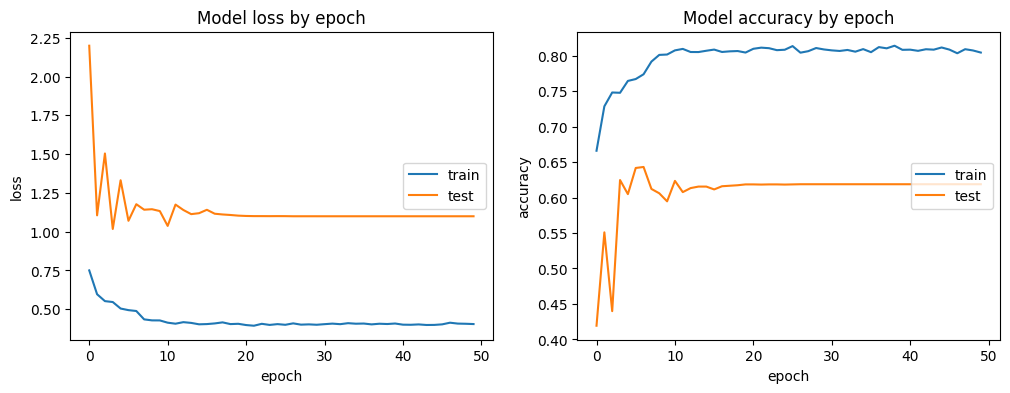

In [15]:
from helper import plot_learning_curve
plot_learning_curve(history_model)

> We can see, that our model accuracy stagnates at appr. 70%
> It seems, that we cannot improve here much.

In [16]:
from tensorflow import keras
vgg16 = keras.models.load_model(model_name)

In [17]:
from helper import get_predictions_and_labels
#y_true, y_pred = get_predictions_and_labels(vgg16, val_ds.take(8)) # for a quick result
y_true, y_pred = get_predictions_and_labels(vgg16, val_ds)

,pre,rec,spe,f1,geo,iba,sup
COVID,0.418811,0.661992,0.813920,0.513043,0.734036,0.530622,713.000000
Lung_Opacity,0.695427,0.691845,0.884941,0.693632,0.782459,0.600421,1165.000000
Normal,0.761131,0.523324,0.844598,0.620213,0.664829,0.427798,2058.000000
Viral Pneumonia,0.496241,0.888889,0.931911,0.636912,0.910146,0.824801,297.000000
avg_pre,0.666803,0.666803,0.666803,0.666803,0.666803,0.666803,0.666803
avg_rec,0.618710,0.618710,0.618710,0.618710,0.618710,0.618710,0.618710
avg_spe,0.856660,0.856660,0.856660,0.856660,0.856660,0.856660,0.856660
avg_f1,0.623539,0.623539,0.623539,0.623539,0.623539,0.623539,0.623539
avg_geo,0.726072,0.726072,0.726072,0.726072,0.726072,0.726072,0.726072
avg_iba,0.520481,0.520481,0.520481,0.520481,0.520481,0.520481,0.520481


Predicted,COVID,Lung_Opacity,Normal,Viral Pneumonia
COVID,472,113,120,8
Lung_Opacity,161,806,197,1
Normal,484,238,1077,259
Viral Pneumonia,10,2,21,264


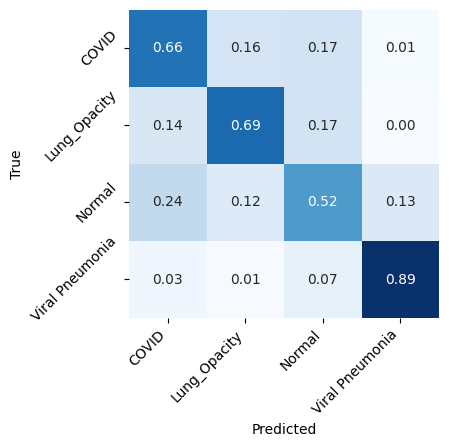

{'crosstab': Predicted        COVID  Lung_Opacity  Normal  Viral Pneumonia
 COVID              472           113     120                8
 Lung_Opacity       161           806     197                1
 Normal             484           238    1077              259
 Viral Pneumonia     10             2      21              264,
 'classification_report':                          pre          rec          spe           f1  \
 COVID               0.418811     0.661992     0.813920     0.513043   
 Lung_Opacity        0.695427     0.691845     0.884941     0.693632   
 Normal              0.761131     0.523324     0.844598     0.620213   
 Viral Pneumonia     0.496241     0.888889     0.931911     0.636912   
 avg_pre             0.666803     0.666803     0.666803     0.666803   
 avg_rec             0.618710     0.618710     0.618710     0.618710   
 avg_spe             0.856660     0.856660     0.856660     0.856660   
 avg_f1              0.623539     0.623539     0.623539     0.623539   

In [18]:
from helper import report_model_performance
report_model_performance(y_true, y_pred, class_names)

# Conclusion: Our model predicts the 4 classes already not too bad
# However, the recall especially for the covid class is the lowest